In [5]:
import sys
from pathlib import Path

parent_folder = Path.cwd().parent
if str(parent_folder) not in sys.path:
    sys.path.append(str(parent_folder))
    
import warnings
warnings.filterwarnings('ignore')

import scienceplots

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('science')
from analysis import Analysis
import nafflib

In [6]:
a = Analysis('data/co_dist/dir_y')
a_dist = Analysis('data/co_dist/dir_distorted_y')
a_ind = Analysis('data/co_dist/ind_y')
a_dist_ind = Analysis('data/co_dist/ind_distorted_y')

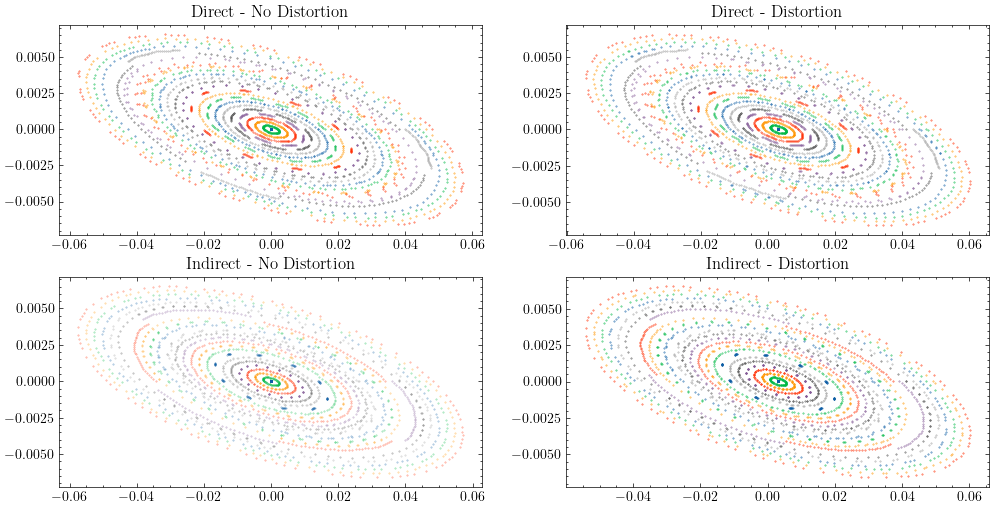

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(12,6))
for particle in range(0, int(a.n_particles/1), 20):
    axs[0,0].scatter(a.x[particle][::100], a.px[particle][::100], marker='.', s=0.5, alpha=0.9)
    axs[1,0].scatter(a_ind.x[particle][::100], a_ind.px[particle][::100], marker='.', s=0.5, alpha=0.5)
    axs[0,1].scatter(a_dist.x[particle][::100], a_dist.px[particle][::100], marker='.', s=0.5, alpha=0.9)
    axs[1,1].scatter(a_dist_ind.x[particle][::100], a_dist_ind.px[particle][::100], marker='.', s=0.5, alpha=0.9)

    axs[0,0].set_title('Direct - No Distortion')
    axs[1,0].set_title('Indirect - No Distortion')
    axs[0,1].set_title('Direct - Distortion')
    axs[1,1].set_title('Indirect - Distortion')

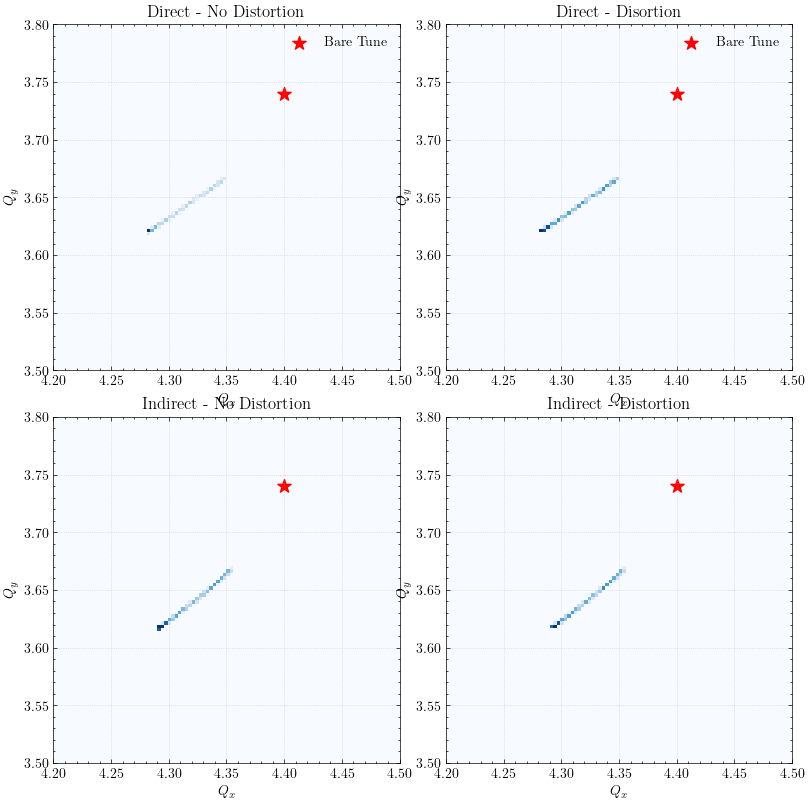

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
fig.subplots_adjust(wspace=0, hspace=0)
plt.tight_layout()
qx = a.qx
qy = a.qy


Qx = a.get_tunes(a.x[a.survivor_mask], a.px[a.survivor_mask], 'x')
Qy = a.get_tunes(a.y[a.survivor_mask], a.py[a.survivor_mask], 'y')
axs[0,0].hist2d(Qx, Qy, bins=100, cmap='Blues', range=[(4.2,4.5), (3.5, 3.8)])
axs[0,0].scatter(qx, qy, marker='*', s=100, c='r', label='Bare Tune')
axs[0,0].set_xlabel(r"$Q_x$")
axs[0,0].set_ylabel(r"$Q_y$")
axs[0,0].set_title(f'Direct - No Distortion')
axs[0,0].legend()
axs[0,0].set_aspect('equal')
axs[0,0].grid(True, linestyle=':', alpha=0.6)


Qx = a_ind.get_tunes(a_ind.x[a_ind.survivor_mask], a_ind.px[a_ind.survivor_mask], 'x')
Qy = a_ind.get_tunes(a_ind.y[a_ind.survivor_mask], a_ind.py[a_ind.survivor_mask], 'y')
axs[1,0].hist2d(Qx, Qy, bins=100, cmap='Blues', range=[(4.2,4.5), (3.5,3.8)])
axs[1,0].scatter(qx, qy, marker='*', s=100, c='r', label='Bare Tune')
axs[1,0].set_xlabel(r"$Q_x$")
axs[1,0].set_ylabel(r"$Q_y$")
axs[1,0].set_title(f'Indirect - No Distortion')
axs[1,0].set_aspect('equal')
axs[1,0].grid(True, linestyle=':', alpha=0.6)


Qx = a_dist.get_tunes(a_dist.x[a_dist.survivor_mask], a_dist.px[a_dist.survivor_mask], 'x')
Qy = a_dist.get_tunes(a_dist.y[a_dist.survivor_mask], a_dist.py[a_dist.survivor_mask], 'y')
axs[0,1].hist2d(Qx, Qy, bins=100, cmap='Blues', range=[(4.2,4.5), (3.5,3.8)])
axs[0,1].scatter(qx, qy, marker='*', s=100, c='r', label='Bare Tune')
axs[0,1].set_xlabel(r"$Q_x$")
axs[0,1].set_ylabel(r"$Q_y$")
axs[0,1].set_title(f'Direct - Disortion')
axs[0,1].legend()
axs[0,1].set_aspect('equal')
axs[0,1].grid(True, linestyle=':', alpha=0.6)


Qx = a_dist_ind.get_tunes(a_dist_ind.x[a_dist_ind.survivor_mask], a_dist_ind.px[a_dist_ind.survivor_mask], 'x')
Qy = a_dist_ind.get_tunes(a_dist_ind.y[a_dist_ind.survivor_mask], a_dist_ind.py[a_dist_ind.survivor_mask], 'y')
axs[1,1].hist2d(Qx, Qy, bins=100, cmap='Blues', range=[(4.2,4.5), (3.5,3.8)])
axs[1,1].scatter(qx, qy, marker='*', s=100, c='r', label='Bare Tune')
axs[1,1].set_xlabel(r"$Q_x$")
axs[1,1].set_ylabel(r"$Q_y$")
axs[1,1].set_title(f'Indirect - Distortion')
axs[1,1].set_aspect('equal')
axs[1,1].grid(True, linestyle=':', alpha=0.6)


fig.savefig('footprints.pdf')